In [13]:
import sys
sys.path.append('..')
from general_settings import *

In [29]:
# Solve forward problem:
from WaveNewmarkFractional import *
c_expr = fn.Constant(c)
alpha = 0.3
# alpha = 0.8
b = (-(2 * c) / np.cos(np.pi * (alpha + 1)/ 2) )
print(b)
b = 66.08/1e3
# b = 31.54/1e3
parameter = [c_expr, b, alpha]

66.08067793755801


In [33]:
# x_opt = np.array([50., 0., 0., 0., 0.])
#x_opt = np.array([86.26273311, 41.98872398, 29.45342825, 23.30126577, 18.99384889])
# x_opt = np.array([ 66.1251,  51.9678, 0., -30.5733592, -51.3337421])
x_opt = np.array([26.58514435, 43.45663502, 45.8251038 , 43.68162209, 40.45149474])
omega = np.array([20 * np.pi, 30 * np.pi, 40 * np.pi, 50 * np.pi, 60 * np.pi])
size_omega = len(omega)

In [34]:
# Observation operator:
u_trial, u_test = fn.TrialFunction(V), fn.TestFunction(V)
B_matrix = fn.assemble(fn.inner(u_trial('+'), u_test('+')) * ds(1))
_misfit = WaveSpaceTimeStateObservation(V, simulation_times, simulation_times, B_matrix)

In [32]:
# gamma = 1.
# delta = 8.
# _prior = LaplacianPrior(V, gamma, delta)
gamma = 0.05
delta = 10.
_prior = BiLaplacianPrior(V, gamma, delta)
from WaveSolver import *
WaveNewModel = WaveInverseDamped(V, simulation_times, _misfit, _prior, parameter)

In [35]:
# Compute u_comp
X_iter_2 = WaveNewModel.generate_vector()
computed_sol = np.load('data_function/bi_03_200_opt_103.npy')
u_comp = init_vector_numpy(computed_sol)
list_i_prime_funcs = np.array([omega[i] * np.cos(omega[i] * simulation_times) for i in range(size_omega)])
i_true_time = x_opt.dot(list_i_prime_funcs)
f_true = space_time_mult(i_true_time, u_comp, M_matrix, simulation_times)
# Zero vectors:
zero_vec = init_vector(M_matrix, 0)
zero_time_vec = init_time_vector(M_matrix, simulation_times, 0)

In [36]:
design = i_true_time
X_zero = WaveNewModel.generate_vector()
X_zero[PARAMETER][:] = u_comp[:]
WaveNewModel.solveFwd(X_zero[STATE], X_zero, design)
WaveNewModel.misfit.p_obs = X_zero[STATE].copy()
WaveNewModel.misfit.noise_variance = 1e-2
parRandom.normal_perturb(WaveNewModel.misfit.noise_variance, WaveNewModel.misfit.p_obs)
print(WaveNewModel.cost(X_zero))
obs = _misfit.observe(X_zero[STATE])

[245.63810167550815, 245.63649676308557, 0.001604912422573114]


In [37]:
def show_solution_new(Vh, ic, state, same_colorbar=True, colorbar=True, mytitle=None, suptitle=None, show_axis='off', logscale=False, times=[0, .4, 1., 2., 3., 4.], cmap=None):
    """
    Plot a :code:TimeDependentVector at specified time steps
    """
    state.store(ic, 0)
    nrows = int(np.ceil(len(times) / 3.))
    subplot_loc = nrows*100 + 30
    plt.figure(figsize=(18,4*nrows))
    plt.suptitle(suptitle, fontsize=25)

    if mytitle is None:
        title_stamp = "Time {0}"
    else:
        title_stamp = mytitle + " at time {0}"

    vmin = None
    vmax = None

    if same_colorbar:
        vmin = 1e30
        vmax = -1e30
        for s in state.data:
            smax = s.max()
            smin = s.min()
            if smax > vmax:
                vmax = smax
            if smin < vmin:
                vmin = smin

    counter=1
    myu = fn.Function(Vh)
    for i in times:
        if np.abs(i) < 1e-10:
            init_func = fn.Function(Vh, ic)
            nb.plot(init_func, subplot_loc=(subplot_loc+counter), mytitle='Reconstructed result', colorbar=colorbar,
                logscale=logscale, show_axis=show_axis, vmin=vmin, vmax=vmax, cmap=cmap)
            counter = counter + 1
        else:
            try:
                state.retrieve(myu.vector(),i)
                nb.plot(myu, subplot_loc=(subplot_loc+counter), mytitle=title_stamp.format(i), colorbar=colorbar,
                logscale=logscale, show_axis=show_axis, vmin=vmin, vmax=vmax, cmap=cmap)
                counter = counter + 1
            except:
                print( "Invalid time: ", i)

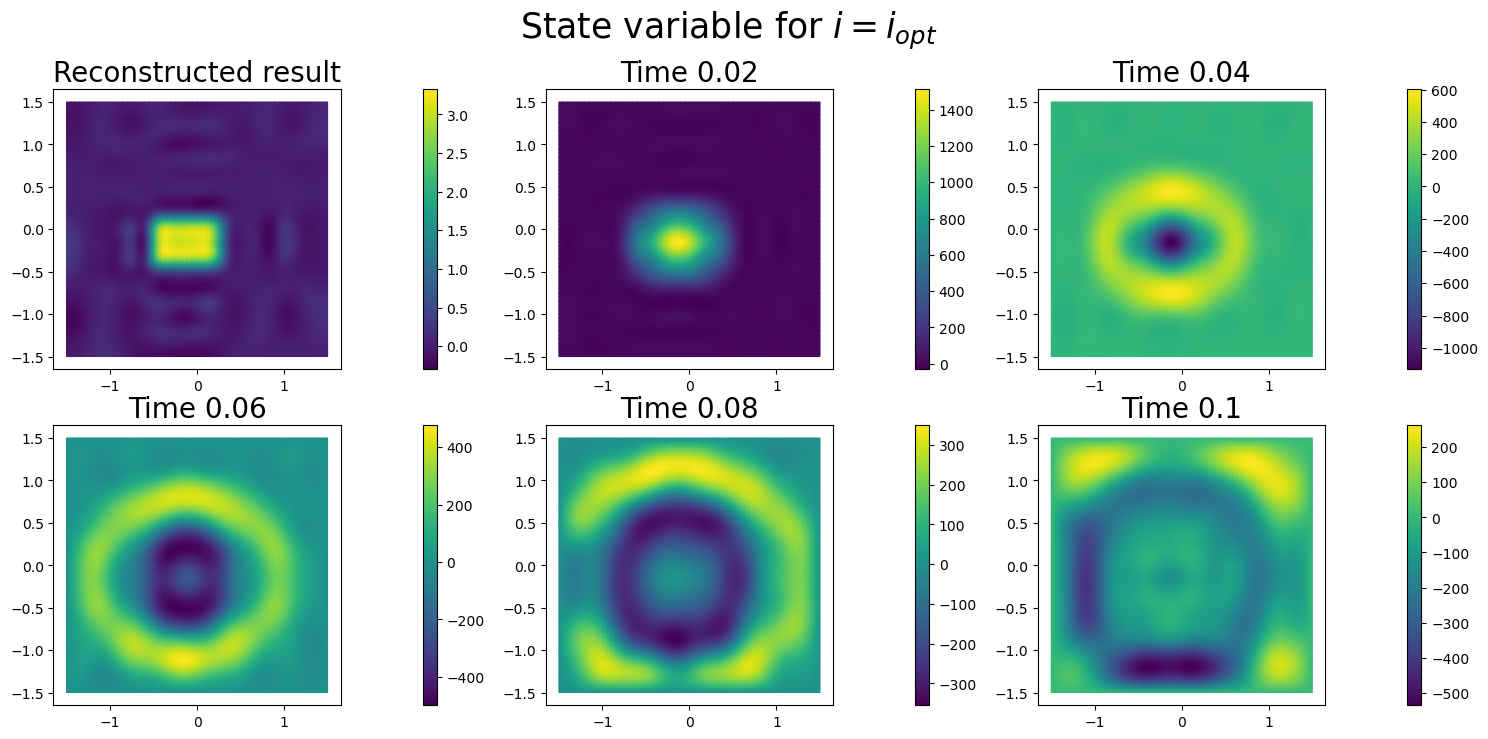

In [38]:
# Plot the state variable X_zero[STATE]:
show_solution_new(V, u_comp, X_zero[STATE], same_colorbar=False,
                  suptitle=r'State variable for $i = i_{opt}$',
                  times=np.array([0., 0.02, 0.04,
                                  0.06, 0.08, 0.1]),
                  show_axis='on')
# Export plot to pdf with short marginal:
plt.savefig('plot_new/03_state_variable_iopt_103.pdf', bbox_inches='tight')

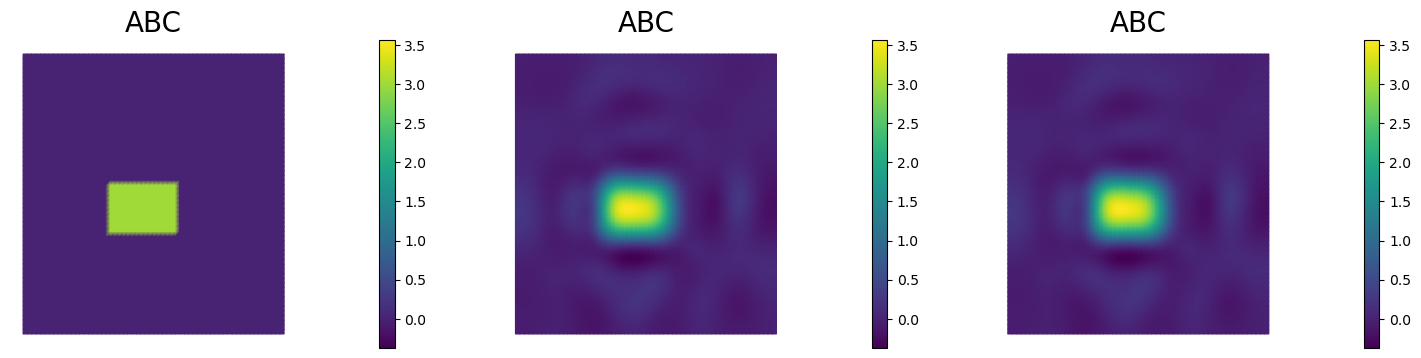

In [35]:
u_30 = init_vector_numpy(np.load('data_function/bi_03_50_init_103.npy'))
u_80 = init_vector_numpy(np.load('data_function/bi_08_50_20init_103.npy'))
nb.multi1_plot([fn.Function(V, u_init), fn.Function(V, u_30), fn.Function(V, u_30)], titles=['', 'ABC', 'ABC'], same_colorbar=True)